# Decoder output content — per-time-bin posterior, likelihood, and decoded hex

Builds tidy DataFrames of **what the decoder actually decided**, one row per 6 ms time bin:
the full posterior, the full likelihood, and the decoded hex (argmax), indexed by a time
base you choose.

## Which clock is which — read this first

The decoder's records carry **two different clocks**, and during playback they refer to
**two different days**. This notebook exposes three time bases:

| Time base | What it is | For the Toby example run |
|---|---|---|
| `trodes_sample` | Integer counter at 30 kHz from the **original recording hardware**. Relative — counts samples since that recording session's streaming began, so it encodes no date by itself. | `732637940 … 796306800` |
| `recording_time` | **When the animal was actually there.** Derived by anchoring the sample counter to the `.rec` file header's `systemTimeAtCreation` / `timestampAtCreation`. | `2025-03-16 17:44 → 18:19` |
| `playback_time` | **When your machine decoded it.** `time.time_ns()` on the decoder host at the moment the record was written. | `2026-08-25 19:38 → 20:24` |

So, answering the question directly:

- The Trodes timestamps (`timestamp`, `bin_timestamp_l/r`) come from the **original recording**.
  They are the scientifically meaningful clock — they align with position, behaviour, and
  anything else derived from that `.rec`.
- Every unix/wall-clock field (`rec_time`, and all `t_*` fields in the timing tables) is the
  **playback** machine's clock — i.e. *now*, when you replayed the file, **not** when the
  animal was recorded. Verified empirically: Trodes stamps a *fresh* `systemTimestamp` during
  playback (`t_recv_data − t_send_data` is ~0.2 ms, not 17 months).
- To get absolute wall time **of the original experiment**, the sample counter must be anchored
  using the `.rec` header. That is what `recording_time` does, and it is the index you almost
  certainly want for analysis.

**Use `recording_time` or `trodes_sample` for science. Use `playback_time` only for performance.**


In [11]:
import os, re, glob, gc, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import oyaml as yaml

PAL  = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
        '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURF, BASE = '#e1e0d9', '#fcfcfb', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': BASE, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2.0, 'font.size': 10.5, 'legend.frameon': False,
    'figure.dpi': 110,
})
def style_ax(ax):
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)


In [31]:
animal = 'Toby'
date = '20250316'
session__id = '03'
epoch = 'r2'

In [32]:
# ---------------- run selection ----------------
RUN_DIR    = f'/media/ssd1/decoder_output/{animal}/{date}_{session__id}_{epoch}'
RUN_PREFIX = None        # None -> newest *.rec_merged.h5 in RUN_DIR
REC_FILE   = None        # None -> derived from the config's .trodesconf path
# 'recording_unix' | 'playback_unix' | 'recording_time' | 'playback_time' | 'trodes_sample'
INDEX_BY   = 'recording_unix'
EXPORT     = False       # write the tables to parquet/csv next to the run

if RUN_PREFIX is None:
    cands = sorted(glob.glob(os.path.join(RUN_DIR, '*.rec_merged.h5')))
    assert cands, f'no *.rec_merged.h5 in {RUN_DIR}'
    RUN_PREFIX = os.path.basename(cands[-1]).replace('.rec_merged.h5', '')

REC = os.path.join(RUN_DIR, RUN_PREFIX + '.rec_merged.h5')
cfg = yaml.safe_load(open(glob.glob(os.path.join(RUN_DIR, RUN_PREFIX + '*.config.yaml'))[0]))

FS       = cfg['sampling_rate']['spikes']
TBIN     = cfg['decoder']['time_bin']['samples']
DELAY    = cfg['decoder']['time_bin']['delay_samples']
POS      = cfg['encoder']['position']
NUM_BINS = POS['num_bins']
IS_HEX   = POS.get('type') == 'hex'
# dense posterior index i  ->  real hex id.  Written into the config snapshot at
# startup by position.resolve_hex_position_config(), so it always matches the run.
HEX_IDS  = list(POS['hex_ids']) if IS_HEX else list(range(NUM_BINS))
STATES   = cfg[cfg['algorithm']]['state_labels']

print(f'run       : {RUN_PREFIX}')
print(f'position  : {POS.get("type", "linear")}  ·  {NUM_BINS} bins')
print(f'hex ids   : {HEX_IDS[:8]} ... {HEX_IDS[-3:]}' if IS_HEX else '')
print(f'time bin  : {TBIN} samples = {TBIN/FS*1e3:.1f} ms   (delay {DELAY/FS*1e3:.1f} ms)')
print(f'states    : {STATES}')


run       : 20260825_184345_Toby_hex_realtime_decoding
position  : hex  ·  49 bins
hex ids   : [1, 2, 3, 4, 5, 6, 7, 8] ... [47, 48, 49]
time bin  : 180 samples = 6.0 ms   (delay 6.0 ms)
states    : ['state']


## 1. Establish the clocks

Reads the original `.rec` header to anchor the sample counter to absolute recording time.
If the `.rec` is unavailable, `recording_time` is skipped and the other two still work.

In [33]:
# ---------------- anchor the Trodes sample clock to the original recording ----------------
if REC_FILE is None:
    tconf = cfg['trodes']['config_file']
    guess = re.sub(r'\.trodesconf$', '.rec', tconf)
    REC_FILE = guess if os.path.exists(guess) else None

REC_ANCHOR = None
if REC_FILE and os.path.exists(REC_FILE):
    with open(REC_FILE, 'rb') as f:
        head = f.read(300_000)
    end = head.find(b'</Configuration>')
    xml = head[:end + 16].decode('utf-8', errors='replace') if end > 0 else ''
    def _attr(name):
        m = re.search(rf'{name}\s*=\s*"([^"]*)"', xml)
        return int(m.group(1).strip()) if m and m.group(1).strip() else None
    sys_ms, ts_at = _attr('systemTimeAtCreation'), _attr('timestampAtCreation')
    if sys_ms and ts_at:
        REC_ANCHOR = (sys_ms, ts_at)
        print(f'.rec anchor found: {os.path.basename(REC_FILE)}')
        print(f'  systemTimeAtCreation = {sys_ms} ms  -> '
              f'{dt.datetime.fromtimestamp(sys_ms/1000):%Y-%m-%d %H:%M:%S}')
        print(f'  timestampAtCreation  = {ts_at} samples')
else:
    print(f'.rec not found ({REC_FILE}) — recording_time unavailable, other clocks still work.')

# All datetimes are reported in this machine's LOCAL timezone, so they line up
# with the run prefix (which runscript.py builds from local datetime.now()).
# Raw epoch-ns values are UTC-based, hence the explicit conversion.
LOCAL_TZ = dt.datetime.now().astimezone().tzinfo
def ns_to_local(ns):
    return pd.to_datetime(np.asarray(ns, np.int64), unit='ns', utc=True).tz_convert(LOCAL_TZ)

def to_recording_ns(ts):
    """Trodes sample count -> unix EPOCH NANOSECONDS of the ORIGINAL recording.

    Single source of truth for the recording clock. Uses float division by FS
    (1e9/30000 = 33333.333... ns per sample); integer division would truncate to
    33333 and accumulate ~22 ms of drift over a 36 min session.
    """
    if REC_ANCHOR is None:
        return np.full(len(np.atleast_1d(ts)), np.nan)
    sys_ms, ts_at = REC_ANCHOR
    return np.rint(sys_ms * 1e6
                   + (np.asarray(ts, np.float64) - ts_at) * (1e9 / FS)).astype(np.int64)

def to_recording_time(ts):
    """Trodes sample count -> absolute local wall time of the ORIGINAL recording."""
    if REC_ANCHOR is None:
        return pd.DatetimeIndex([pd.NaT] * len(np.atleast_1d(ts)))
    return ns_to_local(to_recording_ns(ts))

print(f'\nreporting all datetimes in local time: {dt.datetime.now().astimezone().tzname()}')


.rec anchor found: 20250316_Toby_03_r2.rec
  systemTimeAtCreation = 1742158127826 ms  -> 2025-03-16 13:48:47
  timestampAtCreation  = 309124031 samples

reporting all datetimes in local time: PDT


## 2. Load the decoder's per-bin output

`rec_4` (`DECODER_OUTPUT`) holds the **posterior**; `rec_6` (`LIKELIHOOD_OUTPUT`) holds the
**likelihood** for the same bins. Both are wide — one column per position bin — so they are
split into scalar metadata and the probability matrices.

In [34]:
# ---------------- load and split ----------------
dig = len(str(NUM_BINS))
POST_COLS = [f'x{v:0{dig}d}_{s}' for s in STATES for v in range(NUM_BINS)]
LIK_COLS  = [f'x{v:0{dig}d}' for v in range(NUM_BINS)]

r4 = pd.read_hdf(REC, 'rec_4')
missing = [c for c in POST_COLS if c not in r4.columns]
assert not missing, f'posterior columns missing from rec_4: {missing[:5]}'

meta = r4[['rec_time', 'timestamp', 'bin_timestamp_l', 'bin_timestamp_r', 'spike_count',
           'task_state', 'cred_int_post', 'cred_int_lk', 'dec_rank', 'velocity',
           'mapped_pos', 'x', 'y']].copy()
# marginalize over states (single state for clusterless_decoder -> unchanged)
post = r4[POST_COLS].to_numpy(np.float64)
if len(STATES) > 1:
    post = post.reshape(len(r4), len(STATES), NUM_BINS).sum(axis=1)
del r4; gc.collect()

r6 = pd.read_hdf(REC, 'rec_6')
lik_meta = r6[['bin_timestamp_l', 'dec_rank']].copy()
lik = r6[LIK_COLS].to_numpy(np.float64)
del r6; gc.collect()

# align likelihood rows to posterior rows on (decoder rank, bin left edge)
order = (pd.MultiIndex.from_frame(lik_meta[['dec_rank', 'bin_timestamp_l']])
         .get_indexer(pd.MultiIndex.from_frame(meta[['dec_rank', 'bin_timestamp_l']])))
assert (order >= 0).all(), 'some posterior bins have no matching likelihood row'
lik = lik[order]

print(f'bins: {len(meta):,}   posterior {post.shape}   likelihood {lik.shape}')
print(f'decoder ranks present: {sorted(meta.dec_rank.unique())}')


bins: 467,097   posterior (467097, 49)   likelihood (467097, 49)
decoder ranks present: [np.int64(1)]


## 3. Build the tables

Three objects sharing one index:

- **`bins`** — one row per time bin, scalar columns (decoded hex, confidence, actual position…)
- **`posterior`** — bins × hex, probability the animal was in that hex
- **`likelihood`** — bins × hex, spike evidence before the transition model is applied

In [35]:
# ---------------- derive per-bin quantities ----------------
hex_arr   = np.asarray(HEX_IDS)
post_arg  = post.argmax(axis=1)
lik_arg   = lik.argmax(axis=1)

bins = pd.DataFrame({
    'trodes_sample'    : meta.bin_timestamp_l.to_numpy(np.int64),   # bin left edge
    'bin_timestamp_r'  : meta.bin_timestamp_r.to_numpy(np.int64),
    'trigger_sample'   : meta.timestamp.to_numpy(np.int64),         # LFP sample that triggered decode
    'playback_time'    : ns_to_local(meta.rec_time.to_numpy(np.int64)),
    'dec_rank'         : meta.dec_rank.to_numpy(int),
    'spike_count'      : meta.spike_count.to_numpy(int),
    'decoded_hex'      : hex_arr[post_arg],
    'posterior_max'    : post.max(axis=1),
    'likelihood_hex'   : hex_arr[lik_arg],
    'likelihood_max'   : lik.max(axis=1),
    'cred_int_post'    : meta.cred_int_post.to_numpy(int),
    'cred_int_lk'      : meta.cred_int_lk.to_numpy(int),
    'task_state'       : meta.task_state.to_numpy(int),
    'velocity'         : meta.velocity.to_numpy(float),
    'x'                : meta.x.to_numpy(float),
    'y'                : meta.y.to_numpy(float),
})
# ---- the four time bases, all describing the same bin ----
bins['recording_unix'] = to_recording_ns(bins.trodes_sample) / 1e9   # unix SECONDS, recording
bins['recording_time'] = to_recording_time(bins.trodes_sample).to_numpy()   # same, readable
bins['playback_unix']  = meta.rec_time.to_numpy(np.int64) / 1e9      # unix SECONDS, playback
bins['bin_seconds']    = (bins.trodes_sample - bins.trodes_sample.iloc[0]) / FS

# actual position: mapped_pos is the DENSE index the decoder was told, not the hex id
mp = meta.mapped_pos.to_numpy()
ok = np.isfinite(mp) & (mp >= 0) & (mp < NUM_BINS)
bins['actual_hex'] = np.where(ok, hex_arr[np.clip(mp, 0, NUM_BINS - 1).astype(int)], -1)

# entropy: how spread out the posterior is (0 = certain, log2(49)=5.6 = uniform)
with np.errstate(divide='ignore', invalid='ignore'):
    bins['posterior_entropy'] = -np.nansum(np.where(post > 0, post * np.log2(post), 0), axis=1)

VALID_INDEX = ('recording_unix', 'playback_unix', 'recording_time',
               'playback_time', 'trodes_sample')
assert INDEX_BY in VALID_INDEX, f'INDEX_BY must be one of {VALID_INDEX}'
idx_col = INDEX_BY
if bins[idx_col].isna().all():
    print(f'!! {INDEX_BY} unavailable (no .rec anchor) — falling back to trodes_sample')
    idx_col = 'trodes_sample'

bins = bins.set_index(idx_col, drop=False)
bins.index.name = idx_col
posterior  = pd.DataFrame(post, index=bins.index, columns=hex_arr)
likelihood = pd.DataFrame(lik,  index=bins.index, columns=hex_arr)
posterior.columns.name = likelihood.columns.name = 'hex'

print(f'indexed by: {idx_col}')
bins


indexed by: recording_unix


,trodes_sample,bin_timestamp_r,trigger_sample,playback_time,dec_rank,spike_count,decoded_hex,posterior_max,likelihood_hex,likelihood_max,...,task_state,velocity,x,y,recording_unix,recording_time,playback_unix,bin_seconds,actual_hex,posterior_entropy
recording_unix,,,,,,,,,,,,,,,,,,,,,
1.742158e+09,310159760,310159940,310160120,2026-08-25 18:43:58.078370294-07:00,1,0,4,0.028884,30,0.021352,...,1,19.706394,574.71,621.01,1.742158e+09,2025-03-16 13:49:22.350299904-07:00,1.787709e+09,0.000,30,5.593732
1.742158e+09,310159940,310160120,310160300,2026-08-25 18:43:58.078686616-07:00,1,0,4,0.026168,30,0.021352,...,1,19.706394,574.71,621.01,1.742158e+09,2025-03-16 13:49:22.356299776-07:00,1.787709e+09,0.006,30,5.602509
1.742158e+09,310160120,310160300,310160480,2026-08-25 18:43:58.079244574-07:00,1,0,4,0.026483,30,0.021352,...,1,19.706394,574.71,621.01,1.742158e+09,2025-03-16 13:49:22.362299904-07:00,1.787709e+09,0.012,30,5.598276
1.742158e+09,310160300,310160480,310160660,2026-08-25 18:43:58.080161940-07:00,1,0,4,0.025826,30,0.021352,...,1,19.706394,574.71,621.01,1.742158e+09,2025-03-16 13:49:22.368299776-07:00,1.787709e+09,0.018,30,5.598640
1.742158e+09,310160480,310160660,310160840,2026-08-25 18:43:58.080847843-07:00,1,0,4,0.025575,30,0.021352,...,1,19.706394,574.71,621.01,1.742158e+09,2025-03-16 13:49:22.374299904-07:00,1.787709e+09,0.024,30,5.597374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.742161e+09,394236320,394236500,394236680,2026-08-25 19:30:40.535783335-07:00,1,0,25,0.054445,23,0.021218,...,1,44.407195,654.65,623.41,1.742161e+09,2025-03-16 14:36:04.902299904-07:00,1.787711e+09,2802.552,25,5.189504
1.742161e+09,394236500,394236680,394236860,2026-08-25 19:30:40.541731874-07:00,1,0,25,0.048812,23,0.021218,...,1,44.407195,654.65,623.41,1.742161e+09,2025-03-16 14:36:04.908299776-07:00,1.787711e+09,2802.558,25,5.259251
1.742161e+09,394236680,394236860,394237040,2026-08-25 19:30:40.547807638-07:00,1,0,25,0.045066,23,0.021218,...,1,44.407195,654.65,623.41,1.742161e+09,2025-03-16 14:36:04.914299904-07:00,1.787711e+09,2802.564,25,5.312681


In [36]:
#here we save the decoded_ouutput dataframe to designated files:


In [37]:
posterior  # rows = time bins, columns = hex ids, values = P(animal in hex)


hex,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
recording_unix,,,,,,,,,,,,,,,,,,,,,
1.742158e+09,1.529137e-02,0.015291,0.015291,2.888370e-02,0.016990,0.016990,0.023787,0.023787,0.016990,0.020388,...,0.023787,2.378658e-02,0.023787,0.016990,0.016990,0.016990,0.016990,0.016990,0.028884,0.028884
1.742158e+09,1.485213e-02,0.014852,0.014852,2.616804e-02,0.018813,0.018813,0.022349,0.022349,0.017540,0.022066,...,0.022349,2.234892e-02,0.022349,0.018813,0.017540,0.017540,0.017540,0.018813,0.026168,0.026168
1.742158e+09,1.395404e-02,0.013954,0.013954,2.648324e-02,0.018382,0.018382,0.023198,0.023198,0.017004,0.021761,...,0.022622,2.262209e-02,0.023198,0.018382,0.017004,0.017004,0.017004,0.018382,0.026483,0.026483
1.742158e+09,1.358406e-02,0.013584,0.013584,2.582608e-02,0.018529,0.018529,0.023012,0.023012,0.017091,0.022316,...,0.022323,2.232338e-02,0.023012,0.018529,0.017106,0.016962,0.017106,0.018529,0.025826,0.025826
1.742158e+09,1.323490e-02,0.013235,0.013235,2.557464e-02,0.018367,0.018367,0.023181,0.023181,0.016987,0.022373,...,0.022380,2.238033e-02,0.023190,0.018367,0.017018,0.016798,0.017018,0.018367,0.025575,0.025575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.742161e+09,1.498204e-03,0.000242,0.002816,3.535356e-03,0.004187,0.002299,0.008071,0.007458,0.006052,0.013115,...,0.040334,4.164164e-02,0.008986,0.007376,0.019487,0.034386,0.016849,0.002400,0.008753,0.001841
1.742161e+09,1.560257e-03,0.000560,0.003401,3.748203e-03,0.004337,0.003052,0.008776,0.009100,0.007443,0.013875,...,0.038144,4.026783e-02,0.011894,0.009128,0.020583,0.032926,0.017967,0.003583,0.009578,0.002399
1.742161e+09,1.639850e-03,0.000847,0.003870,4.126722e-03,0.004617,0.003671,0.009658,0.010472,0.008677,0.014517,...,0.036297,3.852291e-02,0.013919,0.010481,0.020932,0.031489,0.018700,0.004869,0.010805,0.003295


### One combined table

`bins`, `posterior`, and `likelihood` share an index, so they concatenate directly. The per-hex
columns are prefixed and zero-padded (`post_hex01 … post_hex49`) so they stay grouped, sort
correctly, and never collide with the scalar column names.

Pull a block back out at any time with `wide.filter(like='post_hex')`.

In [38]:
# ---------------- join bins + posterior (+ likelihood) into one wide table ----------------
INCLUDE_LIKELIHOOD = True

assert bins.index.equals(posterior.index), 'bins / posterior index mismatch'
pad   = max(2, len(str(max(HEX_IDS))))
parts = [bins, posterior.rename(columns=lambda h: f'post_hex{h:0{pad}d}')]
if INCLUDE_LIKELIHOOD:
    assert bins.index.equals(likelihood.index), 'bins / likelihood index mismatch'
    parts.append(likelihood.rename(columns=lambda h: f'lik_hex{h:0{pad}d}'))

wide = pd.concat(parts, axis=1)
assert not wide.columns.duplicated().any(), 'duplicate column names after join'
assert len(wide) == len(bins), 'row count changed during join'

print(f'wide {wide.shape}   {wide.memory_usage(deep=True).sum()/1e6:.0f} MB   '
      f'indexed by {wide.index.name}')
print(f'  {bins.shape[1]} scalar + {len(HEX_IDS)} posterior'
      + (f' + {len(HEX_IDS)} likelihood' if INCLUDE_LIKELIHOOD else '') + ' columns')

preview = ['trodes_sample', 'recording_time', 'spike_count',
           'decoded_hex', 'posterior_max', 'actual_hex']
preview += [c for c in wide.columns if c.startswith('post_hex')][:3]
wide

wide (467097, 120)   452 MB   indexed by recording_unix
  22 scalar + 49 posterior + 49 likelihood columns


,trodes_sample,bin_timestamp_r,trigger_sample,playback_time,dec_rank,spike_count,decoded_hex,posterior_max,likelihood_hex,likelihood_max,...,lik_hex40,lik_hex41,lik_hex42,lik_hex43,lik_hex44,lik_hex45,lik_hex46,lik_hex47,lik_hex48,lik_hex49
recording_unix,,,,,,,,,,,,,,,,,,,,,
1.742158e+09,310159760,310159940,310160120,2026-08-25 18:43:58.078370294-07:00,1,0,4,0.028884,30,0.021352,...,0.020388,2.038850e-02,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388
1.742158e+09,310159940,310160120,310160300,2026-08-25 18:43:58.078686616-07:00,1,0,4,0.026168,30,0.021352,...,0.020388,2.038850e-02,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388
1.742158e+09,310160120,310160300,310160480,2026-08-25 18:43:58.079244574-07:00,1,0,4,0.026483,30,0.021352,...,0.020388,2.038850e-02,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388
1.742158e+09,310160300,310160480,310160660,2026-08-25 18:43:58.080161940-07:00,1,0,4,0.025826,30,0.021352,...,0.020388,2.038850e-02,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388
1.742158e+09,310160480,310160660,310160840,2026-08-25 18:43:58.080847843-07:00,1,0,4,0.025575,30,0.021352,...,0.020388,2.038850e-02,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388,0.020388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.742161e+09,394236320,394236500,394236680,2026-08-25 19:30:40.535783335-07:00,1,0,25,0.054445,23,0.021218,...,0.019644,2.095851e-02,0.020912,0.020754,0.020114,0.021070,0.020107,0.020895,0.020433,0.020429
1.742161e+09,394236500,394236680,394236860,2026-08-25 19:30:40.541731874-07:00,1,0,25,0.048812,23,0.021218,...,0.019644,2.095851e-02,0.020912,0.020754,0.020114,0.021070,0.020107,0.020895,0.020433,0.020429
1.742161e+09,394236680,394236860,394237040,2026-08-25 19:30:40.547807638-07:00,1,0,25,0.045066,23,0.021218,...,0.019644,2.095851e-02,0.020912,0.020754,0.020114,0.021070,0.020107,0.020895,0.020433,0.020429


In [39]:
from pathlib import Path

path = Path(f'/media/ssd1/decoder_output_merged/{animal}/{animal}_{date}_{session__id}_{epoch}_decoded_merged.pkl')
path.parent.mkdir(parents=True, exist_ok=True)   # creates every missing level, no error if it exists
wide.to_pickle(path)


## 4. Sanity checks

Confirms the tables mean what the column names claim.

In [9]:
checks = []
psum = posterior.sum(axis=1)
checks.append(('posterior rows sum to 1', bool(np.allclose(psum, 1, atol=1e-6)),
               f'min {psum.min():.6f} max {psum.max():.6f}'))
lsum = likelihood.sum(axis=1)
checks.append(('likelihood rows sum to 1', bool(np.allclose(lsum, 1, atol=1e-6)),
               f'min {lsum.min():.6f} max {lsum.max():.6f}'))
checks.append(('argmax matches decoded_hex',
               bool((posterior.columns[posterior.to_numpy().argmax(1)] == bins.decoded_hex).all()),
               'recomputed from the matrix'))
step = np.diff(bins.trodes_sample.to_numpy())
checks.append((f'bins tile at {TBIN} samples', (step == TBIN).mean() > 0.999,
               f'{(step != TBIN).sum()} gaps of {len(step)}'))
checks.append(('index is unique', bool(bins.index.is_unique),
               f'{len(bins) - bins.index.nunique()} duplicates'))
checks.append(('decoded hex ids are valid', bool(bins.decoded_hex.isin(hex_arr).all()),
               f'{bins.decoded_hex.nunique()} distinct hexes decoded of {len(hex_arr)}'))
for name, ok, detail in checks:
    print(f'  [{"OK " if ok else "!!"}] {name}: {detail}')

print()
print(f'span (recording clock) : {bins.recording_time.min()}  ->  {bins.recording_time.max()}')
print(f'span (playback clock)  : {bins.playback_time.min()}  ->  {bins.playback_time.max()}')
neural_min = (bins.trodes_sample.iloc[-1] - bins.trodes_sample.iloc[0]) / FS / 60
wall_min   = (bins.playback_time.iloc[-1] - bins.playback_time.iloc[0]).total_seconds() / 60
print(f'{neural_min:.1f} min of neural data decoded in {wall_min:.1f} min of wall time '
      f'({neural_min/wall_min:.2f}x realtime)')


  [OK ] posterior rows sum to 1: min 1.000000 max 1.000000
  [OK ] likelihood rows sum to 1: min 1.000000 max 1.000000
  [OK ] argmax matches decoded_hex: recomputed from the matrix
  [OK ] bins tile at 180 samples: 61 gaps of 199043
  [OK ] index is unique: 0 duplicates
  [OK ] decoded hex ids are valid: 46 distinct hexes decoded of 49

span (recording clock) : 2025-03-16 17:44:05.129099776-07:00  ->  2025-03-16 18:19:27.418433280-07:00
span (playback clock)  : 2026-08-25 19:38:34.516264251-07:00  ->  2026-08-25 20:24:37.719803733-07:00
35.4 min of neural data decoded in 46.1 min of wall time (0.77x realtime)


## 5. Decoding error

For a hex maze, **graph distance** (how many hex steps apart) is the meaningful error metric —
Euclidean distance would ignore walls and barriers. Both are computed here.

In [10]:
# ---------------- all-pairs hex graph distance (BFS, 49 nodes) ----------------
graph_dist = None
pos_of = {h: i for i, h in enumerate(HEX_IDS)}   # hex id -> dense index
if IS_HEX and os.path.exists(POS['hex_graph_file']):
    edges = pd.read_csv(POS['hex_graph_file'])
    adj = {h: set() for h in HEX_IDS}
    for a, b in edges.itertuples(index=False):
        if a in adj and b in adj:
            adj[a].add(b); adj[b].add(a)
    n = len(HEX_IDS)
    graph_dist = np.full((n, n), -1, int)
    for src in HEX_IDS:
        d, frontier = {src: 0}, [src]
        while frontier:
            nxt = []
            for u in frontier:
                for v in adj[u]:
                    if v not in d:
                        d[v] = d[u] + 1; nxt.append(v)
            frontier = nxt
        for h, dist in d.items():
            graph_dist[pos_of[src], pos_of[h]] = dist
    print(f'hex graph: {n} nodes, {sum(len(v) for v in adj.values())//2} edges, '
          f'max separation {graph_dist.max()} steps')

valid = bins.actual_hex > 0
if graph_dist is not None:
    ai = pd.Series(bins.actual_hex).map(pos_of).to_numpy()
    di = pd.Series(bins.decoded_hex).map(pos_of).to_numpy()
    err = np.where(valid, graph_dist[np.clip(ai,0,None).astype(int),
                                     np.clip(di,0,None).astype(int)], np.nan)
    bins['error_hex_steps'] = err

# euclidean error from centroids (pixels)
if IS_HEX and os.path.exists(POS['hex_centroid_file']):
    cen = pd.read_csv(POS['hex_centroid_file']).set_index('hex')[['x', 'y']]
    A = cen.reindex(bins.actual_hex).to_numpy(float)
    Dd = cen.reindex(bins.decoded_hex).to_numpy(float)
    bins['error_px'] = np.where(valid, np.hypot(*(A - Dd).T), np.nan)

# Validation: the animal's REAL trajectory must move between adjacent hexes.
# If mapped_pos were being mis-decoded into hex ids, successive positions would
# jump around the maze at random, so this is a direct check of that conversion.
if graph_dist is not None:
    a = bins.loc[valid, 'actual_hex'].to_numpy()
    ai_v = np.array([pos_of[h] for h in a])
    steps = graph_dist[ai_v[:-1], ai_v[1:]]
    steps = steps[steps >= 0]
    print(f'actual-position continuity: {(steps == 0).mean()*100:.1f} % of consecutive '
          f'position samples stay in the same hex, {(steps <= 1).mean()*100:.1f} % stay '
          f'within 1 hex step (a real trajectory should be near 100 %)')
    print()

cols = [c for c in ('error_hex_steps', 'error_px') if c in bins]
if cols:
    print()
    print(bins.loc[valid, cols].describe().loc[['mean', '50%', '75%', 'max']].round(2))
    exact = (bins.loc[valid, 'error_hex_steps'] == 0).mean() * 100
    near  = (bins.loc[valid, 'error_hex_steps'] <= 1).mean() * 100
    print(f'\nexact hex match: {exact:.1f} %   ·   within 1 hex step: {near:.1f} %')


hex graph: 49 nodes, 63 edges, max separation 12 steps
actual-position continuity: 97.7 % of consecutive position samples stay in the same hex, 99.9 % stay within 1 hex step (a real trajectory should be near 100 %)


      error_hex_steps  error_px
mean             5.07    329.75
50%              5.00    336.79
75%              7.00    497.39
max             12.00    831.43

exact hex match: 7.3 %   ·   within 1 hex step: 21.3 %


## 6. Look at it

A slice of the posterior over time with the animal's true hex overlaid — the standard way to
eyeball whether decoding is tracking behaviour.

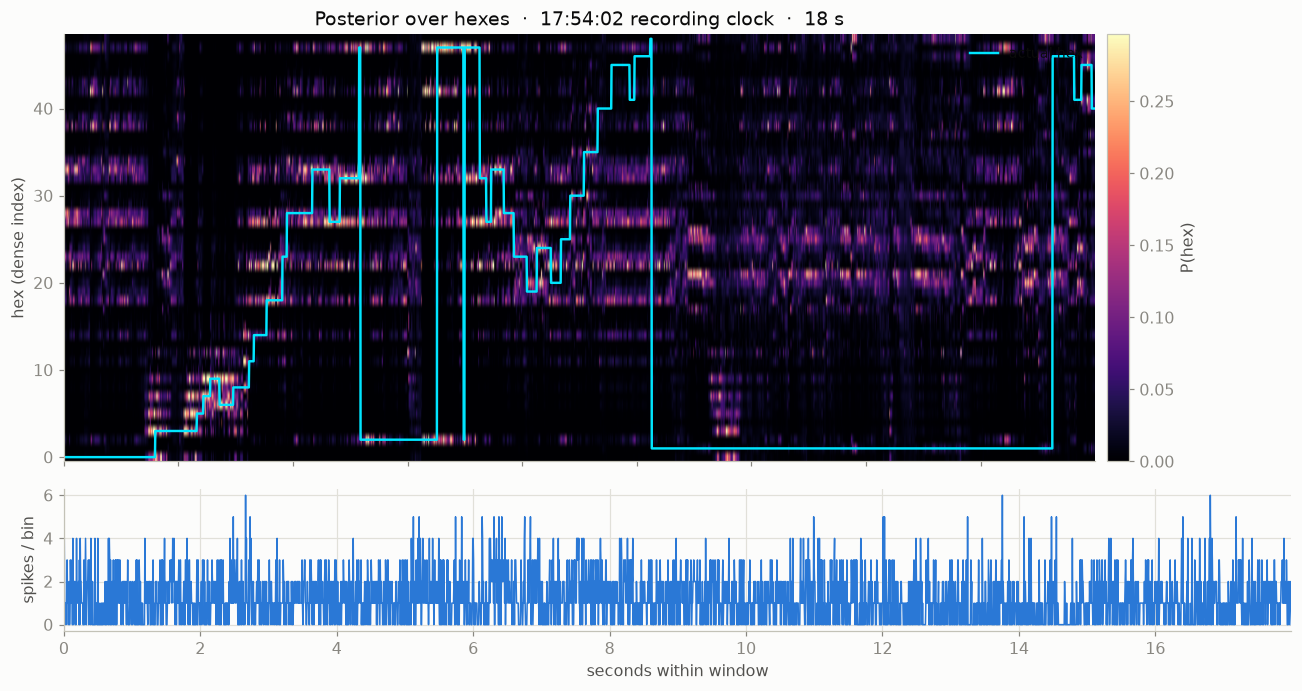

In [11]:
# ---------------- posterior heatmap for a window ----------------
WINDOW_BINS  = 3000                      # 3000 x 6 ms = 18 s
start = int(len(bins) * 0.5)             # midpoint of the session
sl = slice(start, start + WINDOW_BINS)

sub_p = posterior.iloc[sl]
sub_b = bins.iloc[sl]
t_rel = sub_b.bin_seconds.to_numpy() - sub_b.bin_seconds.iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
im = axes[0].imshow(sub_p.to_numpy().T, aspect='auto', origin='lower', cmap='magma',
                    extent=[t_rel[0], t_rel[-1], -0.5, len(hex_arr) - 0.5],
                    vmin=0, vmax=np.percentile(sub_p.to_numpy(), 99.5))
ok_m = sub_b.actual_hex > 0
axes[0].plot(t_rel[ok_m.to_numpy()],
             pd.Series(sub_b.actual_hex[ok_m]).map(pos_of).to_numpy(),
             color='#00e5ff', lw=1.6, label='actual hex')
axes[0].set_ylabel('hex (dense index)')
axes[0].set_title(f'Posterior over hexes  ·  {sub_b.recording_time.iloc[0]:%H:%M:%S} '
                  f'recording clock  ·  {WINDOW_BINS*TBIN/FS:.0f} s')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], pad=0.01, label='P(hex)')

axes[1].plot(t_rel, sub_b.spike_count, color=PAL[0], lw=1)
axes[1].set_ylabel('spikes / bin'); axes[1].set_xlabel('seconds within window')
style_ax(axes[1])
fig.tight_layout(); plt.show()


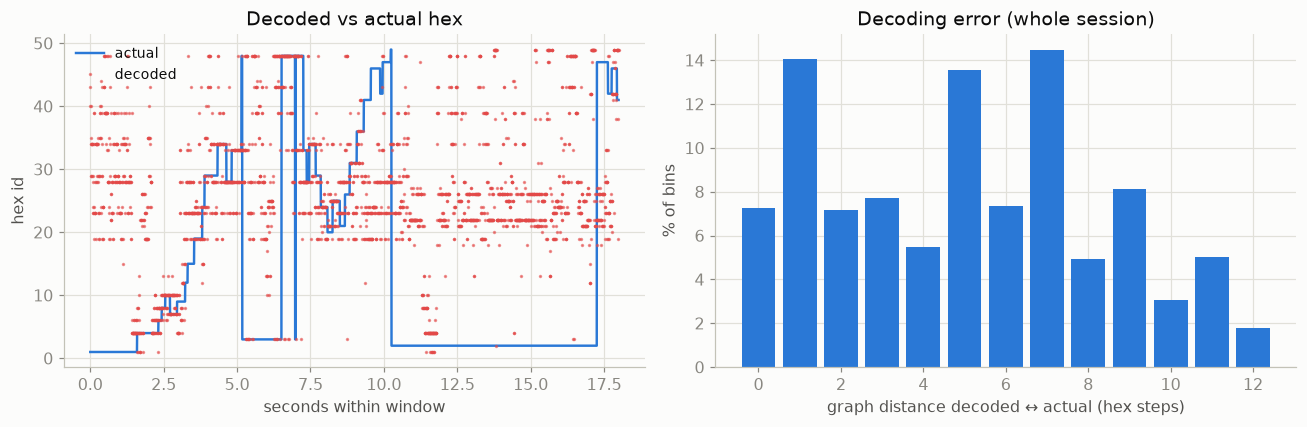

In [12]:
# ---------------- decoded vs actual, and error distribution ----------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

s = bins.iloc[sl]
m = s.actual_hex > 0
axes[0].plot(t_rel[m.to_numpy()], s.actual_hex[m], color=PAL[0], lw=1.6, label='actual')
axes[0].plot(t_rel, s.decoded_hex, color=PAL[7], lw=0, marker='.', ms=2.5,
             alpha=0.55, label='decoded')
axes[0].set_xlabel('seconds within window'); axes[0].set_ylabel('hex id')
axes[0].set_title('Decoded vs actual hex'); axes[0].legend(fontsize=9)
style_ax(axes[0])

if 'error_hex_steps' in bins:
    e = bins.loc[bins.actual_hex > 0, 'error_hex_steps'].dropna()
    vc = e.value_counts().sort_index()
    axes[1].bar(vc.index, vc.values / vc.sum() * 100, color=PAL[0], width=0.82)
    axes[1].set_xlabel('graph distance decoded ↔ actual (hex steps)')
    axes[1].set_ylabel('% of bins')
    axes[1].set_title('Decoding error (whole session)')
    style_ax(axes[1])
fig.tight_layout(); plt.show()


## 7. Using and exporting the tables

```python
bins.loc['2025-03-16 17:50':'2025-03-16 17:51']          # time slice (recording clock)
posterior.loc[bins.spike_count > 5]                       # bins with real evidence
posterior.iloc[100]                                       # full distribution for one bin
bins.decoded_hex.value_counts()                           # where the decoder spent its time
bins.groupby('actual_hex').error_hex_steps.mean()         # error by true location
```

Swap `INDEX_BY` in the config cell to re-index by `trodes_sample` or `playback_time`.

In [13]:
if EXPORT:
    out = os.path.join(RUN_DIR, 'content_analysis', RUN_PREFIX)
    os.makedirs(out, exist_ok=True)
    bins.to_parquet(os.path.join(out, 'bins.parquet'))
    posterior.to_parquet(os.path.join(out, 'posterior.parquet'))
    likelihood.to_parquet(os.path.join(out, 'likelihood.parquet'))
    print('written to', out)
else:
    print('EXPORT is False — set it True in the config cell to write parquet files.')

print(f'\nbins       {bins.shape}  indexed by {bins.index.name}')
print(f'posterior  {posterior.shape}')
print(f'likelihood {likelihood.shape}')


EXPORT is False — set it True in the config cell to write parquet files.

bins       (199044, 24)  indexed by recording_unix
posterior  (199044, 49)
likelihood (199044, 49)


## Caveats

- **`mapped_pos` is a dense index, not a hex id.** The decoder stores the position mapper's
  internal 0-based index; `actual_hex` converts it back through the run config's `hex_ids`.
  Never read `mapped_pos` as a hex label directly.
- **`actual_hex = -1` means position was unavailable** for that bin (tracking lost, or before
  the first position sample). Those bins are excluded from error statistics.
- **The posterior is recursive.** Each bin's posterior folds in the previous bin's through the
  transition matrix, so consecutive rows are *not* independent. The likelihood is the
  instantaneous spike evidence for that bin alone — use it when you need independence.
- **Zero-spike bins still produce a posterior.** With no spikes the likelihood contributes only
  the no-spike term, and the posterior mostly reflects the transition model applied to the
  previous bin. Filter on `spike_count > 0` if that matters.
- **`recording_time` is derived, not recorded.** It assumes the sample counter ran continuously
  from `timestampAtCreation` at exactly `FS` Hz. Good to well under a second over a session, but
  it is a reconstruction — the raw `trodes_sample` is the ground truth.
- **Dropped spikes affect content.** If the run dropped a large fraction of spikes (see
  `time_analysis/decoder_efficiency_analysis.ipynb`), posteriors are built from partial evidence
  and decoding quality will understate what the model could do offline.
